In [1]:
import mlflow
import duckdb
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns

import pandas as pd
import os
import dotenv

dotenv.load_dotenv()
import sys
sys.path.append('/Users/aycha.tammour/geospatial_mlops')

from scripts.feature_eng import TimeSeriesFeatureEngineer
from scripts.process_ts import DataAnalysis
from scripts.forecast_ts import ForecastTS

In [2]:
bucket_name = os.getenv('S3_BUCKET_NAME')
dir_name = 'spectral_indices_ts/'
print(f"{bucket_name=}/{dir_name}")

bucket_name='spectral-indices-monitoring'/spectral_indices_ts/


In [3]:
conn = duckdb.connect()
conn.execute("LOAD spatial;")

In [4]:

# conn.execute("""CREATE SECRET (
#                 TYPE s3,
#                 PROVIDER credential_chain
#                 );
#             """)

In [5]:
location_name = 'atamah_camp'

In [6]:
q = f"""
DESCRIBE
SELECT *
FROM read_parquet('s3://{bucket_name}/spectral_indices_ts/**/*.parquet')
WHERE aoi_name = '{location_name}'
LIMIT 1;
"""
results = conn.execute(q).fetchall()
print(results)

[('time', 'TIMESTAMP_NS', 'YES', None, None, None), ('ndvi', 'FLOAT', 'YES', None, None, None), ('bsi', 'FLOAT', 'YES', None, None, None), ('ndmi', 'FLOAT', 'YES', None, None, None), ('nbr', 'FLOAT', 'YES', None, None, None), ('aoi_name', 'VARCHAR', 'YES', None, None, None), ('geometry', 'GEOMETRY', 'YES', None, None, None)]


In [7]:
q = f"""
SELECT COUNT(*) AS count
FROM read_parquet('s3://spectral-indices-monitoring/spectral_indices_ts/**/*.parquet')
WHERE aoi_name = '{location_name}';
"""

results = conn.execute(q).fetchall()
print(results)

[(399,)]


In [8]:
q = f"""
SELECT *, ST_AsText(geometry) as geometry_wkt, 
        ST_AREA(geometry) AS bbox_area
FROM read_parquet('s3://{bucket_name}/spectral_indices_ts/**/*.parquet')
WHERE aoi_name = 'qastal_maaf'
AND time > '2018-01-01';
"""

results_df = conn.execute(q).df()
print(results_df.shape)
print(results_df['time'].dt.date.min(), results_df['time'].dt.date.max())
results_df.head()

(812, 9)
2018-03-02 2026-03-10


,time,ndvi,bsi,ndmi,nbr,aoi_name,geometry,geometry_wkt,bbox_area
0,2018-03-02 08:29:50.118,0.528687,-0.129868,0.192150,0.377045,qastal_maaf,"[2, 4, 0, 0, 0, 0, 0, 0, 76, 173, 15, 66, 28, ...","POLYGON ((35.98476171697137 34.79698282675849,...",0.003541
1,2018-03-12 08:29:03.369,0.542290,-0.138499,0.205148,0.389395,qastal_maaf,"[2, 4, 0, 0, 0, 0, 0, 0, 76, 173, 15, 66, 28, ...","POLYGON ((35.98476171697137 34.79698282675849,...",0.003541
2,2018-03-12 08:30:19.994,0.601644,-0.153526,0.211052,0.401514,qastal_maaf,"[2, 4, 0, 0, 0, 0, 0, 0, 76, 173, 15, 66, 28, ...","POLYGON ((35.98476171697137 34.79698282675849,...",0.003541
3,2018-03-12 08:30:21.818,0.594924,-0.152576,0.225140,0.416650,qastal_maaf,"[2, 4, 0, 0, 0, 0, 0, 0, 76, 173, 15, 66, 28, ...","POLYGON ((35.98476171697137 34.79698282675849,...",0.003541
4,2018-03-27 08:23:21.611,0.515664,-0.100478,0.182637,0.372588,qastal_maaf,"[2, 4, 0, 0, 0, 0, 0, 0, 76, 173, 15, 66, 28, ...","POLYGON ((35.98476171697137 34.79698282675849,...",0.003541


In [9]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5000'


In [10]:
# mlflow.search_experiments()

In [11]:
# mlflow.set_experiment("geospatial-ml")

In [12]:
data = results_df.copy()
data.set_index('time', inplace=True)
data.sort_index(inplace=True)
data = data.drop(columns=['geometry', 'geometry_wkt', 'bbox_area', 'aoi_name'])
data.head()

,ndvi,bsi,ndmi,nbr
time,,,,
2018-03-02 08:29:50.118,0.528687,-0.129868,0.192150,0.377045
2018-03-12 08:29:03.369,0.542290,-0.138499,0.205148,0.389395
2018-03-12 08:30:19.994,0.601644,-0.153526,0.211052,0.401514
2018-03-12 08:30:21.818,0.594924,-0.152576,0.225140,0.416650
2018-03-27 08:23:21.611,0.515664,-0.100478,0.182637,0.372588


In [13]:
da = DataAnalysis()
smoothed = da.preprocess_time_series(['ndvi', 'bsi', 'ndmi', 'nbr'], data)
# data = data.resample('D').mean().interpolate(method='time')
# smoothed.tail(n=20)

In [14]:
feat_eng = TimeSeriesFeatureEngineer(smoothed)

In [15]:
data = feat_eng.generate_lag_features(spec_index='bsi_smooth', lags=[1, 2])

In [16]:
data.tail()

,ndvi_smooth,bsi_smooth,ndmi_smooth,nbr_smooth,bsi_smooth_lag_1,bsi_smooth_lag_2
time,,,,,,
2026-02-15,0.539510,-0.090640,0.164536,0.347010,-0.096246,-0.101851
2026-02-22,0.531947,-0.085035,0.159588,0.339508,-0.090640,-0.096246
2026-03-01,0.545340,-0.087606,0.164143,0.349966,-0.085035,-0.090640
2026-03-08,0.579689,-0.098354,0.178201,0.378384,-0.087606,-0.085035
2026-03-15,0.585567,-0.102121,0.179665,0.370466,-0.098354,-0.087606


In [17]:
data = feat_eng.generate_datetime_features()

In [18]:
data = feat_eng.generate_aggregate_features('bsi_smooth', [1,2])
data.head()

,ndvi_smooth,bsi_smooth,ndmi_smooth,nbr_smooth,bsi_smooth_lag_1,bsi_smooth_lag_2,year,month,season,bsi_smooth_rolling_mean_1,bsi_smooth_rolling_mean_2
time,,,,,,,,,,,
2018-03-04,0.528687,-0.129868,0.192150,0.377045,NaN,NaN,2018,3,Spring,-0.129868,NaN
2018-03-11,0.541420,-0.134451,0.197558,0.383413,-0.129868,NaN,2018,3,Spring,-0.134451,-0.132159
2018-03-18,0.566886,-0.143617,0.208373,0.396151,-0.134451,-0.129868,2018,3,Spring,-0.143617,-0.139034
2018-03-25,0.563630,-0.136270,0.205995,0.395037,-0.143617,-0.134451,2018,3,Spring,-0.136270,-0.139943
2018-04-01,0.531653,-0.112408,0.190423,0.380071,-0.136270,-0.143617,2018,4,Spring,-0.112408,-0.124339


In [19]:
# with mlflow.start_run():
    
#     mlflow.log_param('data-preprocessing', 'target encoding')

In [21]:
forecaster = ForecastTS('forecasting_bsi')

In [22]:
data.isna().sum()

ndvi_smooth                  0
bsi_smooth                   0
ndmi_smooth                  0
nbr_smooth                   0
bsi_smooth_lag_1             1
bsi_smooth_lag_2             2
year                         0
month                        0
season                       0
bsi_smooth_rolling_mean_1    0
bsi_smooth_rolling_mean_2    1
dtype: int64

In [23]:
data.dropna(inplace=True)

In [24]:
pred = forecaster.forecast(data, target_indx='bsi')

Columns used for forecasting: ['bsi_smooth', 'bsi_smooth_lag_1', 'bsi_smooth_lag_2', 'bsi_smooth_rolling_mean_1', 'bsi_smooth_rolling_mean_2']


2026/03/18 21:15:08 INFO mlflow.tracking.fluent: Experiment with name 'forecasting_bsi' does not exist. Creating a new experiment.


Best Parameters: {'estimator__max_depth': 10, 'estimator__n_estimators': 50}
MAPE: 0.4564464210517977
MAE: 0.011174226778399396
🏃 View run bright-steed-379 at: http://127.0.0.1:5000/#/experiments/3/runs/e715141ae26d481bac9afec1d49c5c15
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [25]:
pred.head()

time
2024-08-11    0.047857
2024-08-18    0.050671
2024-08-25    0.039269
2024-09-01    0.039579
2024-09-08    0.041484
Name: bsi_smooth, dtype: float64

In [45]:
data['rolling_average'] = data['bsi_smooth'].rolling(4,center=False).mean()
data['rolling_std'] = data['bsi_smooth'].rolling(4, center=False).std()

Text(0, 0.5, 'BSI Value')

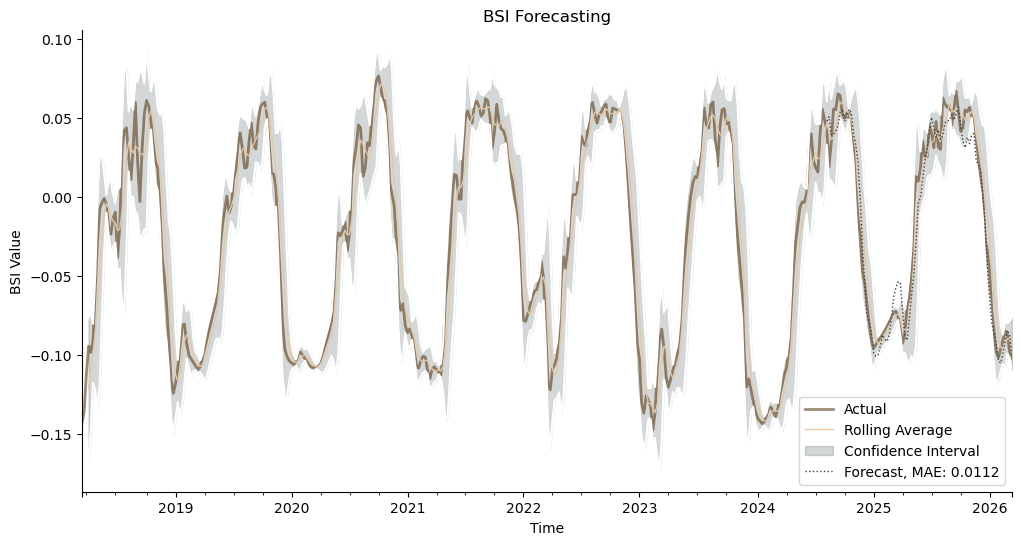

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))
    
data['bsi_smooth'].plot(label='Actual', 
                        ax=ax,
                        lw=2,
                        color='#5a3c1a',
                        alpha=0.6)

data['rolling_average'].plot(ax=ax, 
                             color='#e5c7a4', 
                             lw=1,
                             label='Rolling Average')
(data['rolling_average'] + (2 * data['rolling_std'])).plot(ax=ax, color='w')
(data['rolling_average'] - (2 * data['rolling_std'])).plot(ax=ax, color='w')

ax.fill_between(data.index, 
                data['rolling_average'] + (2 * data['rolling_std']), 
                data['rolling_average'] - (2 * data['rolling_std']), 
                color='#2a3b40', alpha=0.2, label='Confidence Interval')


pred.plot(label='Forecast, MAE: 0.0112', ax=ax, lw=1, color='#424242', ls=':')


sns.despine()
plt.legend()
plt.title('BSI Forecasting')
plt.xlabel('Time')
plt.ylabel('BSI Value')